# What is going to be LeBron's next team??

This project was created to answer that question! Using past year data (2025-26 season) gathered from the nba_api, as well as the capital size left for each team for the 2026 season and merged them into a master table 

In [122]:
import pandas as pd
from nba_api.stats.static import players, teams
from nba_api.stats.endpoints import teamestimatedmetrics, playerestimatedmetrics
import matplotlib as mp
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.colors as cl

In [123]:
lbj = players.find_players_by_full_name('Lebron James')
lbj

[{'id': 2544,
  'full_name': 'LeBron James',
  'first_name': 'LeBron',
  'last_name': 'James',
  'is_active': True}]

In [124]:
lbj_id = lbj[0]['id']

In [125]:
all_teams = teams.get_teams()

In [126]:
lal = [team for team in all_teams if team['abbreviation'] == 'LAL'][0]
cle = [team for team in all_teams if team['abbreviation'] == 'CLE'][0]
nyk = [team for team in all_teams if team['abbreviation'] == 'NYK'][0]
gsw = [team for team in all_teams if team['abbreviation'] == 'GSW'][0]
mia = [team for team in all_teams if team['abbreviation'] == 'MIA'][0]
team_ids = [lal['id'], gsw['id'],cle['id'],nyk['id'],mia['id']]

In [127]:
team_metrics = teamestimatedmetrics.TeamEstimatedMetrics(season='2025-26')
team_metrics_df = team_metrics.get_data_frames()[0]
team_metrics_df

,TEAM_NAME,TEAM_ID,GP,W,L,W_PCT,MIN,E_OFF_RATING,E_DEF_RATING,E_NET_RATING,...,MIN_RANK,E_OFF_RATING_RANK,E_DEF_RATING_RANK,E_NET_RATING_RANK,E_AST_RATIO_RANK,E_OREB_PCT_RANK,E_DREB_PCT_RANK,E_REB_PCT_RANK,E_TM_TOV_PCT_RANK,E_PACE_RANK
0,Miami Heat,1610612748,82,43,39,0.524,3941.0,113.9,111.7,2.2,...,30,13,11,12,9,17,8,13,4,1
1,Chicago Bulls,1610612741,82,31,51,0.378,3951.0,110.5,115.5,-4.9,...,14,23,22,22,7,27,6,15,21,2
2,Utah Jazz,1610612762,82,22,60,0.268,3966.0,111.2,119.2,-8.0,...,6,21,29,27,5,12,24,21,22,3
3,Atlanta Hawks,1610612737,82,46,36,0.561,3951.0,113.2,110.9,2.3,...,14,14,10,14,2,20,10,19,8,4
4,Dallas Mavericks,1610612742,82,26,56,0.317,3971.0,108.5,113.7,-5.2,...,4,27,20,23,24,26,16,25,13,4
5,Memphis Grizzlies,1610612763,82,25,57,0.305,3946.0,109.7,115.4,-5.8,...,26,25,25,25,12,19,29,28,19,6
6,Washington Wizards,1610612764,82,17,65,0.207,3951.0,108.2,119.7,-11.5,...,25,29,30,30,26,21,30,30,24,7
7,Portland Trail Blazers,1610612757,82,42,40,0.512,3951.0,110.6,110.9,-0.3,...,14,22,13,20,30,2,25,7,30,8
8,Indiana Pacers,1610612754,82,19,63,0.232,3951.0,108.5,116.2,-7.7,...,14,28,24,26,11,29,17,29,14,9
9,New Orleans Pelicans,1610612740,82,26,56,0.317,3961.0,111.4,115.7,-4.3,...,10,20,23,21,28,8,28,23,10,10


In [128]:
req_teams_df = team_metrics_df[team_metrics_df['TEAM_ID'].isin(team_ids)]
req_teams_df

,TEAM_NAME,TEAM_ID,GP,W,L,W_PCT,MIN,E_OFF_RATING,E_DEF_RATING,E_NET_RATING,...,MIN_RANK,E_OFF_RATING_RANK,E_DEF_RATING_RANK,E_NET_RATING_RANK,E_AST_RATIO_RANK,E_OREB_PCT_RANK,E_DREB_PCT_RANK,E_REB_PCT_RANK,E_TM_TOV_PCT_RANK,E_PACE_RANK
0,Miami Heat,1610612748,82,43,39,0.524,3941.0,113.9,111.7,2.2,...,30,13,11,12,9,17,8,13,4,1
11,Cleveland Cavaliers,1610612739,82,52,30,0.634,3951.0,116.3,112.3,4.0,...,14,6,15,8,6,9,12,8,9,12
18,Golden State Warriors,1610612744,82,37,45,0.451,3961.0,112.0,112.5,-0.5,...,8,18,17,19,4,14,22,24,27,18
21,Los Angeles Lakers,1610612747,82,53,29,0.646,3941.0,115.7,114.0,1.7,...,29,7,19,12,15,22,13,12,18,22
26,New York Knicks,1610612752,82,53,29,0.646,3951.0,116.8,110.5,6.3,...,14,2,8,5,10,5,2,4,12,27


In [129]:
player_metrics = playerestimatedmetrics.PlayerEstimatedMetrics(season='2025-26')
player_metrics_df = player_metrics.get_data_frames()[0]
player_metrics_df[:5]

,PLAYER_ID,PLAYER_NAME,GP,W,L,W_PCT,MIN,E_OFF_RATING,E_DEF_RATING,E_NET_RATING,...,E_OFF_RATING_RANK,E_DEF_RATING_RANK,E_NET_RATING_RANK,E_AST_RATIO_RANK,E_OREB_PCT_RANK,E_DREB_PCT_RANK,E_REB_PCT_RANK,E_TOV_PCT_RANK,E_USG_PCT_RANK,E_PACE_RANK
0,1642267,Bub Carrington,82,17,65,0.207,27.7,106.8,121.8,-15.0,...,466,538,540,69,521,358,444,42,273,115
1,1629750,Javonte Green,82,60,22,0.732,17.6,112.2,104.2,8.0,...,254,38,66,537,246,303,283,42,420,155
2,1642847,Jeremiah Fears,82,26,56,0.317,25.8,110.8,117.6,-6.9,...,313,481,421,274,407,332,372,42,72,157
3,1641739,Toumani Camara,82,42,40,0.512,33.3,112.2,112.2,0.1,...,254,270,246,348,243,357,335,42,354,164
4,1630643,Jay Huff,82,19,63,0.232,21.0,107.4,113.3,-5.9,...,447,321,395,402,272,219,240,42,255,191


In [130]:
lbj_metrics = player_metrics_df[player_metrics_df['PLAYER_ID'] == lbj_id]

In [131]:
import re
url = "https://www.basketball-reference.com/contracts/players.html#all_player-contracts"
raw_sal_df = pd.read_html(url)[0]
raw_sal_df[:5]

Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0       Salary  \
                  Rk             Player                 Tm      2025-26   
0                  1      Stephen Curry                GSW  $59,606,817   
1                  2        Joel Embiid                PHI  $55,224,526   
2                  3       Nikola Jokić                DEN  $55,224,526   
3                  4       Kevin Durant                HOU  $54,708,609   
4                  5       Jayson Tatum                BOS  $54,126,450   

                                                               \
       2026-27      2027-28      2028-29      2029-30 2030-31   
0  $62,587,158          NaN          NaN          NaN     NaN   
1  $58,100,000  $62,748,000  $67,396,000          NaN     NaN   
2  $59,033,114  $62,841,702          NaN          NaN     NaN   
3  $43,902,439  $46,097,561          NaN          NaN     NaN   
4  $58,456,566  $62,786,682  $67,116,798  $71,446,914     NaN   

  Unnamed: 9_level_0  
          Guaranteed  
0       $122,193,975  
1       $176,072,526  
2       $114,257,640  
3        $98,611,048  
4       $242,486,496

In [132]:
raw_sal_df.columns = raw_sal_df.columns.droplevel(0)

In [133]:
sal_df = pd.DataFrame()

sal_df['PlayerName'] = raw_sal_df['Player']
sal_df['Team'] = raw_sal_df['Tm']
sal_df['2026-27_Salary'] = raw_sal_df['2026-27']
sal_df

,PlayerName,Team,2026-27_Salary
0,Stephen Curry,GSW,"$62,587,158"
1,Joel Embiid,PHI,"$58,100,000"
2,Nikola Jokić,DEN,"$59,033,114"
3,Kevin Durant,HOU,"$43,902,439"
4,Jayson Tatum,BOS,"$58,456,566"
...,...,...,...
577,Tre Scott,BRK,NaN
578,Adama-Alpha Bal,MEM,NaN
579,Malachi Smith,BRK,NaN
580,Lucas Williamson,MEM,NaN


In [134]:
def cleanup(x):
    if pd.isna(x) or str(x).strip() == 'nan':
        return 0
    clean_str = re.sub(r'[\$,]', '', str(x))
    try:
        return int(clean_str)
    except ValueError:
        return 0

In [135]:
sal_df['2026-27_Salary'] = sal_df['2026-27_Salary'].apply(cleanup)

In [136]:
sal_df = sal_df.rename(columns={"PlayerName":"PLAYER_NAME"})

In [137]:
import unicodedata
def normalize_name(name):
    name = str(name).lower()

    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )
    name = name.replace(' jr.', '').replace(' sr.', '').replace(' iii', '').replace(' ii', '')
    name = name.replace("'", "").replace(".", "").strip()
    return name

player_metrics_df['JOIN_NAME'] = player_metrics_df['PLAYER_NAME'].apply(normalize_name)
sal_df['JOIN_NAME'] = sal_df['PLAYER_NAME'].apply(normalize_name)

master_df = pd.merge(player_metrics_df, sal_df, on="JOIN_NAME")
# master_df = master_df.drop(columns=['JOIN_NAME'])

In [138]:
team_sal_df = sal_df.groupby('Team')["2026-27_Salary"].sum().reset_index()
team_sal_df['cap_space'] = 165_000_000 - team_sal_df['2026-27_Salary']
team_sal_df

,Team,2026-27_Salary,cap_space
0,ATL,153088971,11911029
1,BOS,180193378,-15193378
2,BRK,123716928,41283072
3,CHI,92955470,72044530
4,CHO,152217879,12782121
5,CLE,222210758,-57210758
6,DAL,149948952,15051048
7,DEN,215482928,-50482928
8,DET,133047899,31952101
9,GSW,181479537,-16479537


In [139]:
teams_ref = pd.DataFrame(all_teams)[["id", "abbreviation"]]

In [140]:
team_sal_df = team_sal_df.merge(teams_ref, left_on="Team", right_on="abbreviation")
team_sal_df = team_sal_df.rename(columns={'id': 'TEAM_ID'})

In [141]:
req_teams_df = req_teams_df.merge(team_sal_df)
req_teams_df = req_teams_df.drop(columns={"Team"})

In [142]:
req_teams_df

,TEAM_NAME,TEAM_ID,GP,W,L,W_PCT,MIN,E_OFF_RATING,E_DEF_RATING,E_NET_RATING,...,E_NET_RATING_RANK,E_AST_RATIO_RANK,E_OREB_PCT_RANK,E_DREB_PCT_RANK,E_REB_PCT_RANK,E_TM_TOV_PCT_RANK,E_PACE_RANK,2026-27_Salary,cap_space,abbreviation
0,Miami Heat,1610612748,82,43,39,0.524,3941.0,113.9,111.7,2.2,...,12,9,17,8,13,4,1,163037112,1962888,MIA
1,Cleveland Cavaliers,1610612739,82,52,30,0.634,3951.0,116.3,112.3,4.0,...,8,6,9,12,8,9,12,222210758,-57210758,CLE
2,Golden State Warriors,1610612744,82,37,45,0.451,3961.0,112.0,112.5,-0.5,...,19,4,14,22,24,27,18,181479537,-16479537,GSW
3,Los Angeles Lakers,1610612747,82,53,29,0.646,3941.0,115.7,114.0,1.7,...,12,15,22,13,12,18,22,105270325,59729675,LAL
4,New York Knicks,1610612752,82,53,29,0.646,3951.0,116.8,110.5,6.3,...,5,10,5,2,4,12,27,205460628,-40460628,NYK


In [143]:
final_teams_df = team_metrics_df.merge(team_sal_df)
final_teams_df = final_teams_df.drop(columns={"Team"})

In [144]:
lbj_pace = lbj_metrics['E_PACE'].values[0]
lbj_rating = lbj_metrics['E_NET_RATING'].values[0]

In [145]:
colors = {
    "WAS": "navy", "UTA": "midnightblue", "TOR": "red", "SAS": "silver", 
    "SAC": "purple", "POR": "darkred", "PHX": "orange", "PHI": "navy", 
    "ORL": "royalblue", "OKC": "dodgerblue", "NYK": "orangered", "NOP": "plum",
    "MIL": "darkgreen", "MIA": "crimson", "MEM": "steelblue", "LAL": "gold", 
    "LAC": "red", "IND": "yellow", "HOU": "red", "GSW": "goldenrod", 
    "DET": "red", "DEN": "midnightblue", "DAL": "royalblue", "CLE": "darkred", 
    "CHA": "teal", "CHI": "crimson", "BOS": "darkgreen", "BKN": "black", 
    "ATL": "red", "MIN": "darkgreen"}

# This is the main function to calculate the best fit for LeBron

In [152]:
def calculate_and_graph_fit_score(df):

    plt.style.use("seaborn-v0_8-whitegrid")
    pos = [(0,0), (0,1),(1,0),(1,1)]

    # calculating pace fit
    df["pace_fit"] = abs(df["E_PACE"] - lbj_pace)
    
    # Make negative cap space default to 0 for easier calculation
    df['cap_space'] = df['cap_space'].clip(lower = 0, upper=50_000_000)

    # list of features for the MinMaxScaler
    features = ["E_NET_RATING", "cap_space", "pace_fit", "E_AST_RATIO", "E_REB_PCT"]
    scaler = MinMaxScaler()
    df[['f_net_rating', 'f_cap_space', 'f_pace_fit', "f_ast_ratio", "f_reb_pct"]] = scaler.fit_transform(df[features])
    df['f_pace_fit'] = 1 - df['f_pace_fit']

    
    all_scores = []
    fig, ax = plt.subplots(nrows=2, ncols = 2, figsize = (10,20))
    for idx, i in enumerate(np.arange(0.1,0.5,0.1)):
        w_net = 0.4  # 40% weight for net rating
        w_cap = i  # Varying weight for cap size
        w_pace = 0.4-i  # Varying weight for pace
        w_ast = 0.1  # 10% weight for assists
        w_reb = 0.1  # 10% weight for rebounds
        df['fit_score'] = (w_net*df['f_net_rating']) + (w_cap*df['f_cap_space']) + (w_pace*df['f_pace_fit']) + \
                        (w_ast*df['f_ast_ratio']) + (w_reb*df['f_reb_pct'])

        
        all_scores.append(df[['abbreviation', 'fit_score']].copy())

        
        
        sorted_df = df[['abbreviation', 'fit_score']].sort_values('abbreviation')
        row,col = pos[idx]
        sorted_df["color"] = sorted_df["abbreviation"].map(colors).fillna("steelblue")
        ax[row,col].barh(sorted_df["abbreviation"], sorted_df["fit_score"], color=sorted_df["color"])
        # plt.xticks(range(len(all_team_scores)), all_team_scores["abbreviation"])
        ax[row,col].tick_params(axis='x', rotation=90)
        ax[row,col].set_title(f"cap space = {i:.1f}, pace = {0.4-i:.1f}")
    fig.suptitle("LEBRON'S BEST TEAM FITS", fontsize=16, fontweight="bold");
    plt.show()

    # I am taking the average of all the above fit scores and placing them into one final table to show
    # the true rankings for the teams.
    avg_scores = pd.concat(all_scores).groupby("abbreviation")["fit_score"].mean().reset_index()
    avg_scores = avg_scores.rename(columns={"fit_score":"avg_fit_score"})
    return avg_scores.sort_values("avg_fit_score", ascending = False)

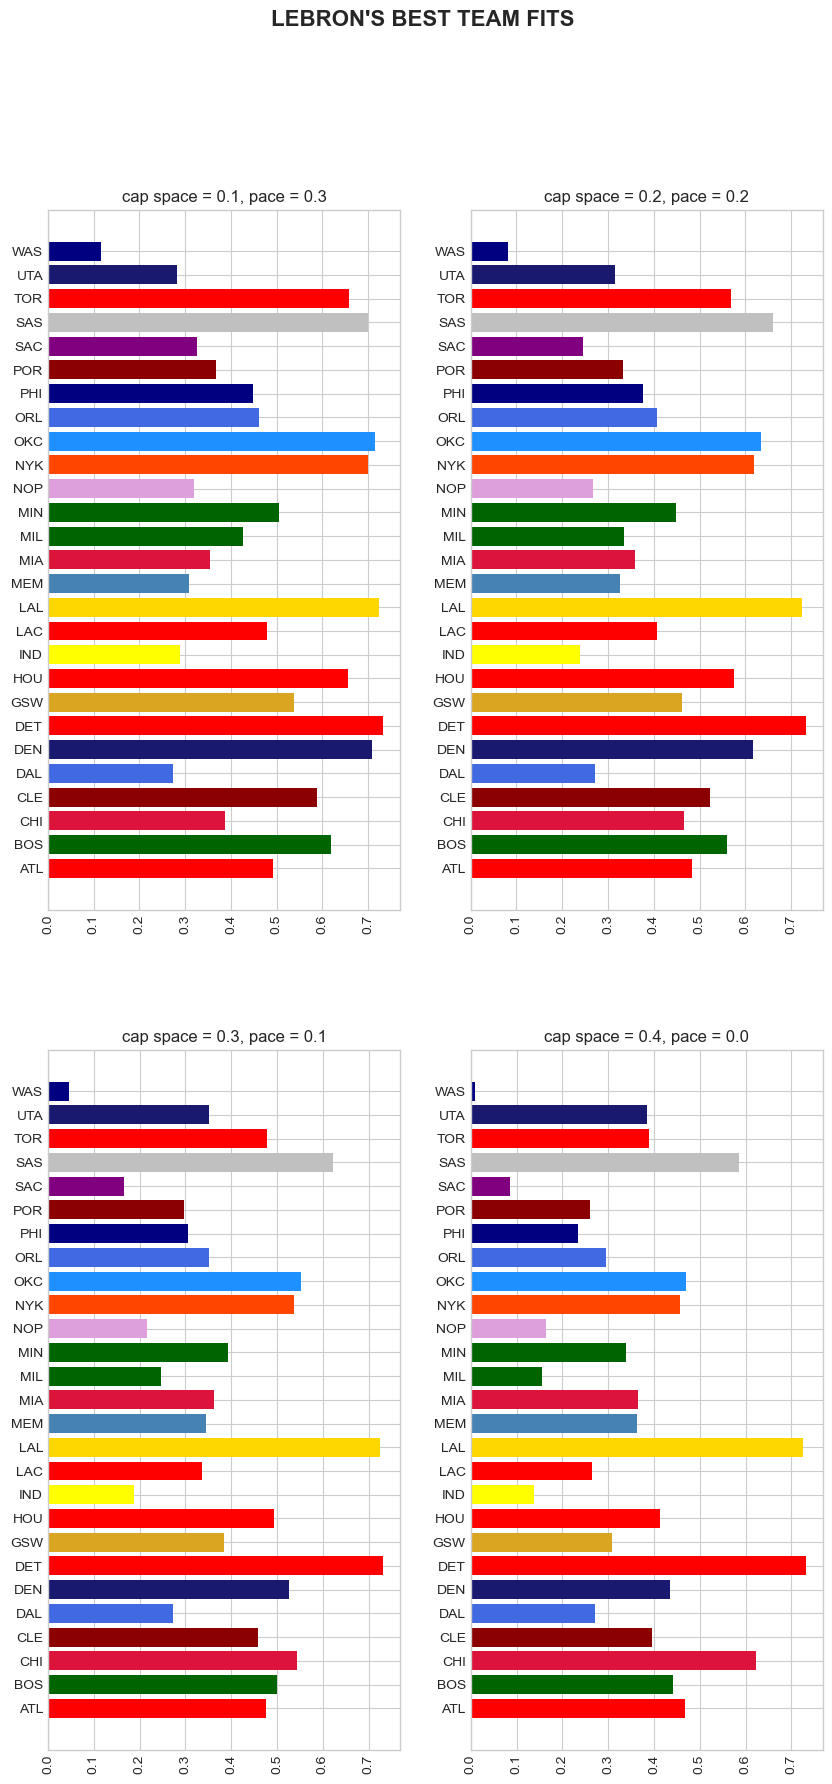

In [153]:
all_team_scores = calculate_and_graph_fit_score(final_teams_df)

In [154]:
all_team_scores

,abbreviation,avg_fit_score
6,DET,0.732773
11,LAL,0.724443
23,SAS,0.642306
18,OKC,0.592505
17,NYK,0.578175
5,DEN,0.570940
8,HOU,0.534437
1,BOS,0.530393
24,TOR,0.523432
2,CHI,0.505063


Now we pass the teams that are actually speculated to be lebron's next teams according to the rumours. When you filter the teams before running the function and pass only the 5 teams into it, MinMaxScaler recalculates the minimum and maximum boundaries using only those 5 teams. Hence the variation in who leads the table.

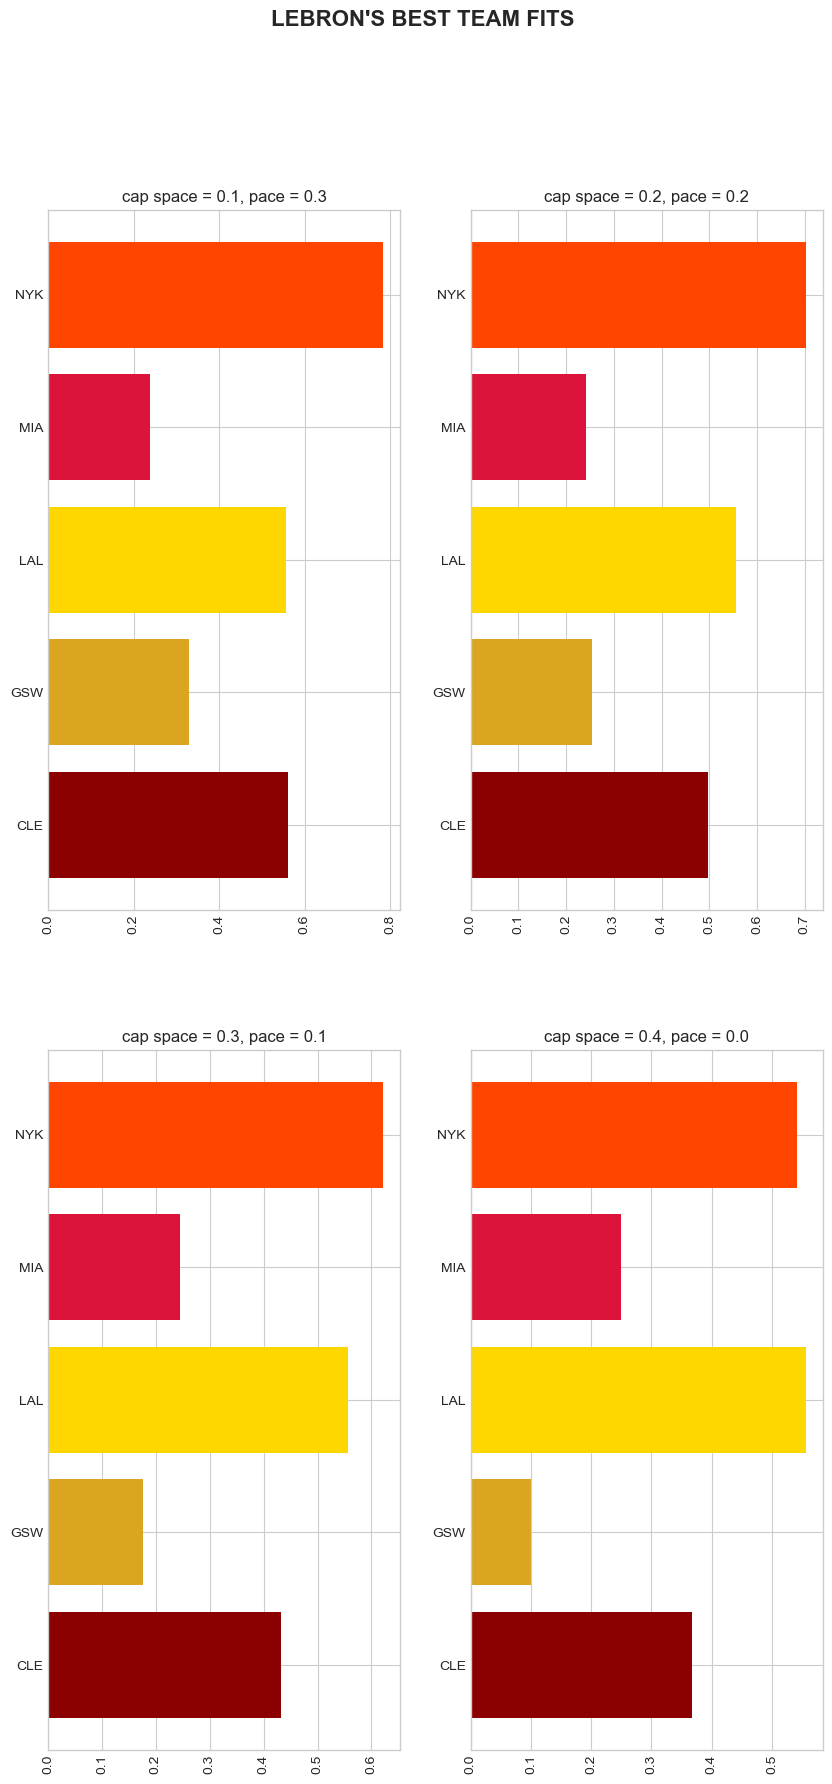

In [155]:
req_teams_scores = calculate_and_graph_fit_score(req_teams_df)

In [156]:
req_teams_scores

,abbreviation,avg_fit_score
4,NYK,0.662738
2,LAL,0.556912
0,CLE,0.464468
3,MIA,0.243638
1,GSW,0.215179


In [158]:
req_abbreviations = ['LAL', 'CLE', 'GSW', 'NYK', 'MIA']
acc_req_teams_scores = all_team_scores[all_team_scores['abbreviation'].isin(req_abbreviations)]
acc_req_teams_scores

,abbreviation,avg_fit_score
11,LAL,0.724443
17,NYK,0.578175
3,CLE,0.491692
7,GSW,0.423285
13,MIA,0.360148


In [159]:
print(final_teams_df[['abbreviation', 'E_NET_RATING', 'E_PACE', 'cap_space']].sort_values('E_NET_RATING', ascending=False))

   abbreviation  E_NET_RATING  E_PACE  cap_space
17          OKC          10.9   101.4          0
13          SAS           8.1   102.5   12231434
15          DET           7.9   102.4   31952101
26          BOS           7.8    98.1          0
23          NYK           6.3    99.3          0
25          HOU           5.2    99.3          0
20          DEN           5.0   100.9          0
11          CLE           4.0   102.4          0
10          MIN           3.2   102.9          0
19          TOR           2.8   101.0          0
3           ATL           2.3   104.2   11911029
0           MIA           2.2   106.0    1962888
21          LAL           1.7   100.4   50000000
24          LAC           1.1    98.8          0
12          ORL           0.6   102.9          0
14          PHI          -0.2   102.0          0
7           POR          -0.3   104.0          0
18          GSW          -0.5   101.7          0
9           NOP          -4.3   103.1          0
1           CHI     